# NB03: Multi-seed evaluation with dynamic feature-set winner selection

Tests three feature engineering methods (raw, alr, pwlr) across four tree
ensembles (RF, ERT, XGB, GB) for both `opx_liq` and `opx_only` tracks. Tuned
once on seed 42 with `HalvingRandomSearchCV` + `StratifiedGroupKFold`, then
frozen hyperparameters are evaluated on 9 additional split seeds (43-51) so
downstream selection can account for across-split variance.

The old factorial design included `raw_aug`, `alr_aug`, `pwlr_aug` variants.
The n_aug sensitivity appendix at the end of this notebook documents the
decision to drop them: see section "Appendix: N_AUG sensitivity".

Outputs:
- `results/nb03_multi_seed_results.csv`
- `results/nb03_winning_configurations.json`
- `results/nb03_canonical_test_predictions.npz`
- `figures/fig05_model_comparison.png` (downstream, from NB06)


In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (
    ROOT, DATA_RAW, DATA_EXTERNAL, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
    MODELS, FIGURES, RESULTS, LOGS,
    EXPETDB, LEPR_XLSX, LIN2023_NATURAL,
    FE3_FET_RATIO, KD_FEMG_MIN, KD_FEMG_MAX, WO_MAX_MOL_PCT,
    P_CEILING_KBAR, CATION_SUM_MIN, CATION_SUM_MAX,
    OXIDE_TOTAL_MIN, OXIDE_TOTAL_MAX,
    SEED_SPLIT, SEED_MODEL, SEED_NOISE_AUG, SEED_KMEANS,
    OPX_RAW_OXIDES, OPX_FULL_OXIDES, LIQ_OXIDES,
)
import warnings
warnings.filterwarnings('ignore')

import json
import logging
import shutil
import time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import (
    GroupShuffleSplit, StratifiedGroupKFold, HalvingRandomSearchCV,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Local vs Colab pathing
if os.path.exists('/content'):
    TEMP_DIR = Path('/content')
else:
    TEMP_DIR = Path.cwd()

FIGS = FIGURES  # alias

In [2]:
# Load cleaned data with chemical cluster labels (written by NB02).
df_all = pd.read_parquet(DATA_PROC / 'opx_clean_core_with_clusters.parquet')
df_all = df_all.reset_index(drop=True)
print(f'Loaded: {len(df_all)} experiments, {df_all["Citation"].nunique()} studies')

df_opx = df_all.copy()
df_liq = df_all[df_all['opx_liq_pair']].reset_index(drop=True).copy()

print(f'Opx-only: {len(df_opx)} rows / {df_opx["Citation"].nunique()} studies')
print(f'Opx-liq:  {len(df_liq)} rows / {df_liq["Citation"].nunique()} studies')


Loaded: 1035 experiments, 123 studies
Opx-only: 1035 rows / 123 studies
Opx-liq:  600 rows / 93 studies


In [3]:
df_liq.to_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')
df_opx.to_parquet(DATA_PROC / 'opx_clean_opx_only.parquet')
print('Track parquet files written.')

Track parquet files written.


In [4]:
# Canonical features and prediction helpers from src/ (one source of truth).
from src.features import (
    build_feature_matrix,
    make_raw_features,
    make_alr_features,
    make_pwlr_features,
    augment_dataframe,
)
from src.models import predict_median, predict_iqr


In [5]:
# Model definitions and global config
N_SPLIT_REPS = 10
SPLIT_SEEDS = list(range(42, 42 + N_SPLIT_REPS))
TUNE_SEED = 42

# 3-method design (no augmentation): N_AUG = 1 makes _aug variants
# mathematically identical to clean, so we drop them.
FEATURE_METHODS = ['raw', 'alr', 'pwlr']
N_AUG = 1  # augmentation disabled per sensitivity test results

HALVING_CV = 3
HALVING_FACTOR = 3
SEARCH_NJOBS = -1     # use all cores for local run
ESTIMATOR_NJOBS = 1   # prevent loky oversubscription

BASE_MODELS = {
    'RF':  lambda: RandomForestRegressor(random_state=SEED_MODEL, n_jobs=ESTIMATOR_NJOBS),
    'ERT': lambda: ExtraTreesRegressor(random_state=SEED_MODEL, n_jobs=ESTIMATOR_NJOBS),
    'XGB': lambda: XGBRegressor(random_state=SEED_MODEL, n_jobs=ESTIMATOR_NJOBS,
                                 verbosity=0, tree_method='hist'),
    'GB':  lambda: HistGradientBoostingRegressor(random_state=SEED_MODEL,
                                                  early_stopping=True,
                                                  validation_fraction=0.15,
                                                  n_iter_no_change=20),
}

PARAM_GRIDS = {
    'RF': {
        'n_estimators': [200, 500, 800],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [0.33, 0.5, 0.66, 'sqrt'],
    },
    'ERT': {
        'n_estimators': [200, 500, 800],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [0.33, 0.5, 0.66, 'sqrt'],
    },
    'XGB': {
        'n_estimators': [200, 500, 800],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'reg_alpha': [0, 0.1, 1, 10],
        'reg_lambda': [1, 5, 10],
    },
    'GB': {
        'max_iter': [200, 500, 800],
        'max_depth': [3, 5, 7, None],
        'learning_rate': [0.01, 0.05, 0.1],
        'min_samples_leaf': [10, 20, 40],
        'l2_regularization': [0.0, 0.1, 1.0],
        'max_leaf_nodes': [15, 31, 63],
    },
}


def tune_with_halving(X_tr, y_tr, X_te, y_te, model_name, target_name,
                      seed, groups_tr):
    """Seed 42 only. HalvingRandomSearchCV, grouped stratified inner CV."""
    base = BASE_MODELS[model_name]()
    grid = PARAM_GRIDS[model_name]
    y_bins = pd.qcut(y_tr, q=5, labels=False, duplicates='drop')
    sgkf = StratifiedGroupKFold(n_splits=HALVING_CV, shuffle=True,
                                random_state=seed)
    cv_iter = list(sgkf.split(X_tr, y_bins, groups=groups_tr))
    search = HalvingRandomSearchCV(
        base, grid, factor=HALVING_FACTOR, resource='n_samples',
        cv=cv_iter, scoring='neg_mean_squared_error',
        random_state=seed, n_jobs=SEARCH_NJOBS, refit=True,
    )
    search.fit(X_tr, y_tr)
    best = search.best_estimator_
    pred_tr = predict_median(best, X_tr)
    pred_te = predict_median(best, X_te)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    return {
        'model': best,
        'best_params': search.best_params_,
        'model_name': model_name,
        'target': target_name,
        'rmse_train': rmse_tr,
        'rmse_test': rmse_te,
        'mae_test': mean_absolute_error(y_te, pred_te),
        'r2_test': r2_score(y_te, pred_te),
        'overfit_ratio': rmse_tr / max(rmse_te, 1e-9),
    }


def eval_frozen(X_tr, y_tr, X_te, y_te, model_name, target_name,
                frozen_params):
    """Seeds 43-51. Clone, set frozen params, single fit."""
    est = clone(BASE_MODELS[model_name]())
    est.set_params(**frozen_params)
    est.fit(X_tr, y_tr)
    pred_tr = predict_median(est, X_tr)
    pred_te = predict_median(est, X_te)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    return {
        'model': est,
        'best_params': frozen_params,
        'model_name': model_name,
        'target': target_name,
        'rmse_train': rmse_tr,
        'rmse_test': rmse_te,
        'mae_test': mean_absolute_error(y_te, pred_te),
        'r2_test': r2_score(y_te, pred_te),
        'overfit_ratio': rmse_tr / max(rmse_te, 1e-9),
    }

## Phase 3R.4: main training loop

Expected: 480 fits (2 tracks x 10 seeds x 3 features x 4 models x 2 targets).
Estimated runtime: 1-2 hours on local hardware with all cores.

In [6]:
# CRITICAL: delete stale checkpoints from prior runs.
# The previous nb03b run had a corrupted frozen_params store that referenced
# 6-method names. With the 3-method design, those keys cause silent skips and
# NaN rows. Always start clean.
PARTIAL_LOCAL = TEMP_DIR / 'nb03c_partial.csv'
FROZEN_LOCAL = TEMP_DIR / 'nb03c_frozen_params.json'

for p in [PARTIAL_LOCAL, FROZEN_LOCAL]:
    if p.exists():
        p.unlink()
        print(f'Deleted stale checkpoint: {p}')
print('Checkpoint state reset. Ready for fresh run.')

Checkpoint state reset. Ready for fresh run.


In [7]:
# Phase 3R.4: 3-method benchmark (clean only)

# ----- logging -----
LOG_PATH = TEMP_DIR / 'nb03c_training.log'
logger = logging.getLogger('nb03c')
logger.setLevel(logging.INFO)
logger.handlers.clear()
_fh = logging.FileHandler(LOG_PATH, mode='w')
_fh.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
_sh = logging.StreamHandler()
_sh.setFormatter(logging.Formatter('%(asctime)s | %(message)s', datefmt='%H:%M:%S'))
logger.addHandler(_fh)
logger.addHandler(_sh)
logger.info('=' * 70)
logger.info(f'Phase 3R.4: 3-method benchmark | N_AUG={N_AUG} | features={FEATURE_METHODS}')

multi_seed_results = []
seed42_models = {}
frozen_params_store = {}
completed_keys = set()

# ----- main loop -----
total = 2 * N_SPLIT_REPS * len(FEATURE_METHODS) * 4 * 2
pbar = tqdm(total=total, desc='Training', smoothing=0.05)
t0_global = time.time()

for track_name, df_track, use_liq in [('opx_liq', df_liq, True),
                                       ('opx_only', df_opx, False)]:
    for seed in SPLIT_SEEDS:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
        tr_pos, te_pos = next(gss.split(df_track,
                                         groups=df_track['Citation'].values))
        df_train = df_track.iloc[tr_pos].copy()
        df_test = df_track.iloc[te_pos].copy()
        assert set(df_train['Citation']).isdisjoint(set(df_test['Citation']))

        for feat_name in FEATURE_METHODS:
            # N_AUG=1 -> augment_dataframe returns df.copy() (identity)
            df_tr_use = df_train

            X_tr, f_names = build_feature_matrix(df_tr_use, feat_name,
                                                     use_liq)
            X_te, _ = build_feature_matrix(df_test, feat_name, use_liq)

            y_T_tr = df_tr_use['T_C'].values
            y_P_tr = df_tr_use['P_kbar'].values
            y_T_te = df_test['T_C'].values
            y_P_te = df_test['P_kbar'].values
            groups_tr = df_tr_use['Citation'].values

            for model_name in ['RF', 'ERT', 'XGB', 'GB']:
                for target_name, y_tr, y_te_arr in [('T_C', y_T_tr, y_T_te),
                                                     ('P_kbar', y_P_tr, y_P_te)]:
                    pbar.set_postfix(trk=track_name, s=seed, f=feat_name,
                                     m=model_name, t=target_name)

                    frozen_key = (track_name, feat_name, model_name,
                                  target_name)
                    t1 = time.time()

                    try:
                        if seed == TUNE_SEED:
                            result = tune_with_halving(
                                X_tr, y_tr, X_te, y_te_arr,
                                model_name, target_name, seed, groups_tr,
                            )
                            frozen_params_store[frozen_key] = result['best_params']
                            seed42_models[(track_name, target_name,
                                           model_name, feat_name)] = \
                                result.pop('model')
                            mode = 'TUNE'
                        else:
                            if frozen_key not in frozen_params_store:
                                logger.error(
                                    f'Missing frozen params: {frozen_key}')
                                pbar.update(1)
                                continue
                            result = eval_frozen(
                                X_tr, y_tr, X_te, y_te_arr,
                                model_name, target_name,
                                frozen_params_store[frozen_key],
                            )
                            result.pop('model')
                            mode = 'FROZEN'

                        elapsed = time.time() - t1
                        result['split_seed'] = seed
                        result['track'] = track_name
                        result['feature_set'] = feat_name
                        multi_seed_results.append(result)

                        logger.info(
                            f'[{mode}] {track_name} s={seed} {feat_name:5s} '
                            f'{model_name:4s} {target_name:7s} '
                            f'rmse={result["rmse_test"]:.2f} '
                            f'r2={result["r2_test"]:.3f} ({elapsed:.0f}s)')
                    except Exception as e:
                        logger.error(f'FAIL {frozen_key}: {type(e).__name__}: {e}')
                    finally:
                        pbar.update(1)

        # checkpoint after every (track, seed)
        pd.DataFrame(multi_seed_results).to_csv(PARTIAL_LOCAL, index=False)
        with open(FROZEN_LOCAL, 'w') as f:
            json.dump(
                {'||'.join(k): {kk: (vv if not isinstance(vv, np.generic)
                                     else vv.item())
                                for kk, vv in v.items()}
                 for k, v in frozen_params_store.items()}, f, default=str)
        elapsed_h = (time.time() - t0_global) / 3600
        logger.info(f'CHECKPOINT {track_name} seed={seed} | '
                    f'{len(multi_seed_results)} rows | {elapsed_h:.2f}h')

pbar.close()

# ----- finalize -----
multi_seed_df = pd.DataFrame(multi_seed_results)

# Sanity check: no NaN rmse_test allowed
n_nan = multi_seed_df['rmse_test'].isna().sum()
if n_nan > 0:
    logger.error(f'CRITICAL: {n_nan} NaN rmse_test rows detected!')
    print(f'WARNING: {n_nan} NaN rows detected. Check log file.')

multi_seed_df['best_params'] = multi_seed_df['best_params'].astype(str)
multi_seed_df.to_csv(RESULTS / 'nb03_multi_seed_results.csv', index=False)

if PARTIAL_LOCAL.exists():
    PARTIAL_LOCAL.unlink()

total_h = (time.time() - t0_global) / 3600
logger.info(f'COMPLETE: {len(multi_seed_df)} rows in {total_h:.2f}h')
print(f'\nComplete: {len(multi_seed_df)} rows in {total_h:.2f}h')
print(f'NaN rows: {n_nan}')

02:45:54 | ======================================================================


02:45:54 | Phase 3R.4: 3-method benchmark | N_AUG=1 | features=['raw', 'alr', 'pwlr']


Training:   0%|          | 0/480 [00:00<?, ?it/s]

02:47:00 | [TUNE] opx_liq s=42 raw   RF   T_C     rmse=89.53 r2=0.583 (67s)


02:47:55 | [TUNE] opx_liq s=42 raw   RF   P_kbar  rmse=5.77 r2=0.642 (54s)


...

03:24:30 | [FROZEN] opx_only s=51 pwlr  GB   T_C     rmse=116.75 r2=0.677 (1s)


03:24:30 | [FROZEN] opx_only s=51 pwlr  GB   P_kbar  rmse=8.62 r2=0.415 (1s)


03:24:30 | CHECKPOINT opx_only seed=51 | 480 rows | 0.64h


03:24:30 | COMPLETE: 480 rows in 0.64h



Complete: 480 rows in 0.64h
NaN rows: 0


## Phase 3R.4b: heatmaps and statistical analysis

Three figures plus printed summary tables:
1. Seed-42 RMSE heatmap (single split, sanity check)
2. 10-seed mean RMSE heatmap with std as overlay
3. Multi-seed boxplot of test RMSE distributions per (model, feature)

In [8]:
# ===== Multi-seed summary table =====
feat_order = ['raw', 'alr', 'pwlr']
model_order = ['RF', 'ERT', 'XGB', 'GB']
panels = [('opx_liq', 'T_C'), ('opx_liq', 'P_kbar'),
          ('opx_only', 'T_C'), ('opx_only', 'P_kbar')]

print('=' * 70)
print('MULTI-SEED RESULTS: mean +/- std test RMSE across 10 splits')
print('=' * 70)
for (track, target), grp in multi_seed_df.groupby(['track', 'target']):
    print(f'\n--- {track} / {target} ---')
    agg = (grp.groupby(['feature_set', 'model_name'])['rmse_test']
           .agg(['mean', 'std']))
    agg['display'] = [f'{m:.2f} +/- {s:.2f}' for m, s in
                      zip(agg['mean'], agg['std'])]
    pivot = agg['display'].unstack('model_name')
    pivot = pivot.reindex(feat_order)[model_order]
    print(pivot.to_string())

MULTI-SEED RESULTS: mean +/- std test RMSE across 10 splits

--- opx_liq / P_kbar ---
model_name              RF            ERT            XGB             GB
feature_set                                                            
raw          5.82 +/- 1.39  6.83 +/- 1.17  5.01 +/- 0.89  5.11 +/- 0.84
alr          6.16 +/- 0.83  7.29 +/- 1.32  5.32 +/- 0.94  5.59 +/- 0.80
pwlr         6.95 +/- 1.26  7.10 +/- 1.43  5.88 +/- 1.37  6.13 +/- 1.24

--- opx_liq / T_C ---
model_name               RF             ERT             XGB              GB
feature_set                                                                
raw          80.47 +/- 7.77  80.46 +/- 7.53  84.27 +/- 7.31  82.03 +/- 6.29
alr          79.02 +/- 7.56  82.61 +/- 7.57  86.58 +/- 9.48  80.80 +/- 6.81
pwlr         78.58 +/- 7.09  80.82 +/- 6.22  87.23 +/- 8.39  89.29 +/- 8.08

--- opx_only / P_kbar ---
model_name               RF             ERT             XGB              GB
feature_set                                     

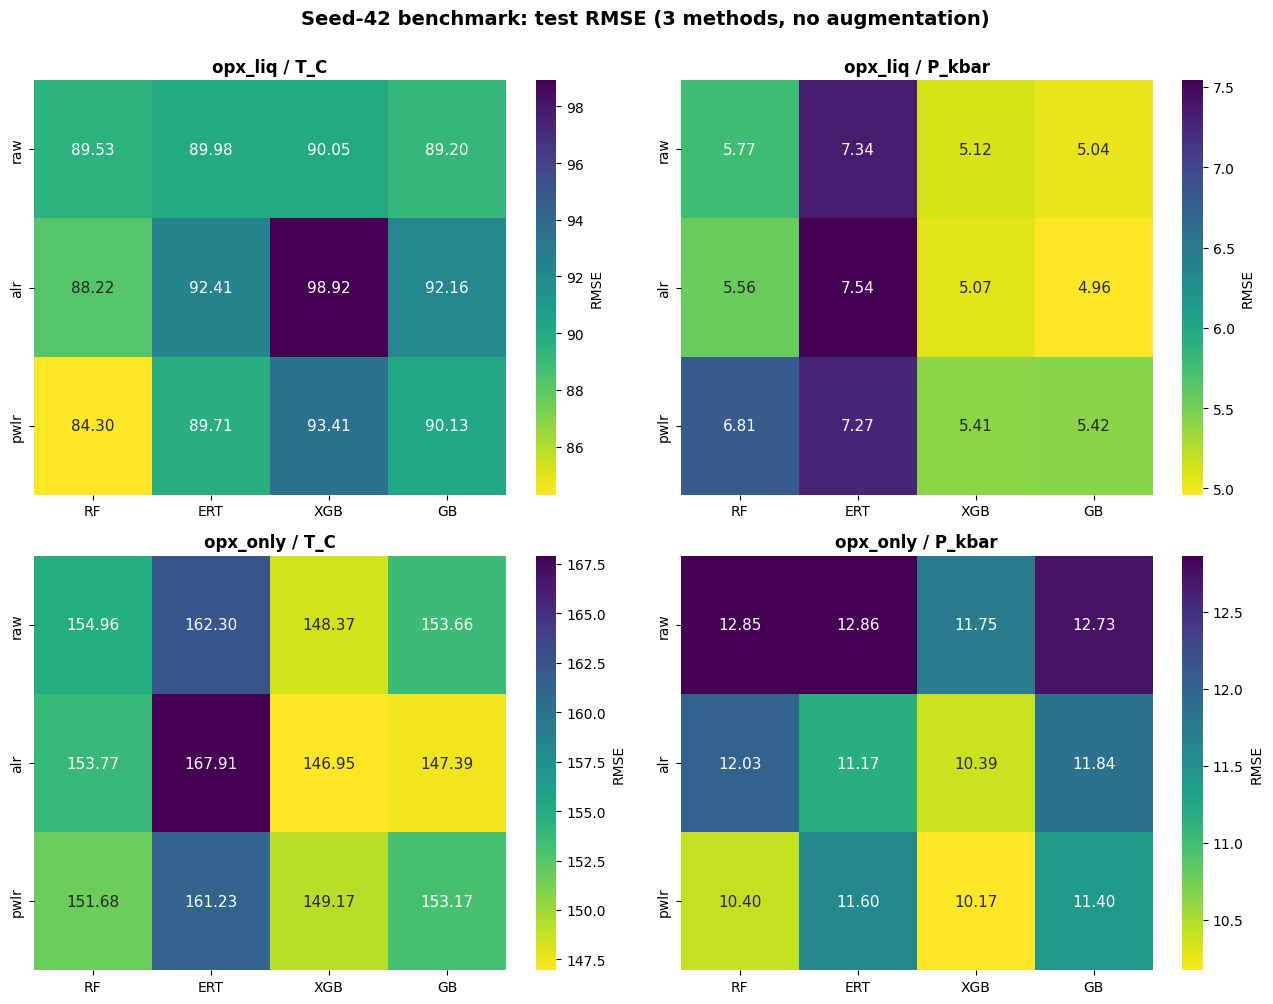

In [9]:
# ===== Seed-42 RMSE heatmap =====
seed42 = multi_seed_df[multi_seed_df['split_seed'] == TUNE_SEED]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (track, target) in zip(axes.flat, panels):
    sub = seed42[(seed42['track'] == track) & (seed42['target'] == target)]
    pivot = sub.pivot(index='feature_set', columns='model_name',
                      values='rmse_test')
    pivot = pivot.reindex(feat_order)[model_order]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis_r',
                ax=ax, cbar_kws={'label': 'RMSE'},
                annot_kws={'size': 11})
    ax.set_title(f'{track} / {target}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Seed-42 benchmark: test RMSE (3 methods, no augmentation)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIGS / 'fig_nb03c_seed42_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

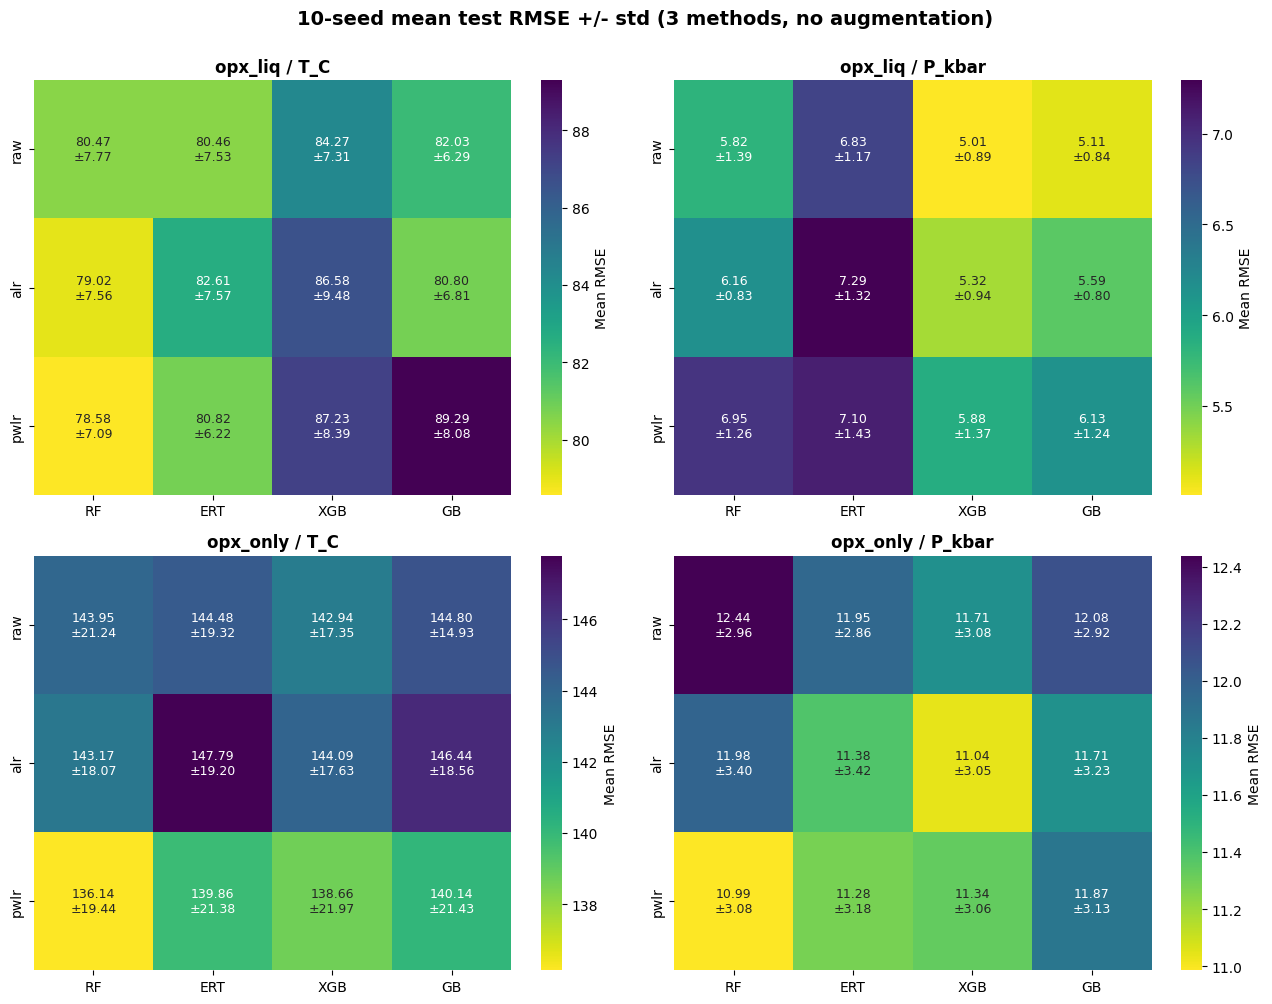

In [10]:
# ===== 10-seed mean RMSE heatmap with std overlay =====
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (track, target) in zip(axes.flat, panels):
    sub = multi_seed_df[(multi_seed_df['track'] == track) &
                        (multi_seed_df['target'] == target)]
    means = sub.groupby(['feature_set', 'model_name'])['rmse_test'].mean()
    stds = sub.groupby(['feature_set', 'model_name'])['rmse_test'].std()

    pivot_mean = means.unstack('model_name').reindex(feat_order)[model_order]
    pivot_std = stds.unstack('model_name').reindex(feat_order)[model_order]

    # build "mean\n+/- std" annotation matrix
    annot = pivot_mean.copy().astype(object)
    for i in range(pivot_mean.shape[0]):
        for j in range(pivot_mean.shape[1]):
            m = pivot_mean.iat[i, j]
            s = pivot_std.iat[i, j]
            annot.iat[i, j] = f'{m:.2f}\n±{s:.2f}'

    sns.heatmap(pivot_mean, annot=annot.values, fmt='', cmap='viridis_r',
                ax=ax, cbar_kws={'label': 'Mean RMSE'},
                annot_kws={'size': 9})
    ax.set_title(f'{track} / {target}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('10-seed mean test RMSE +/- std (3 methods, no augmentation)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIGS / 'fig_nb03c_multiseed_rmse.png', dpi=300,
            bbox_inches='tight')
plt.show()

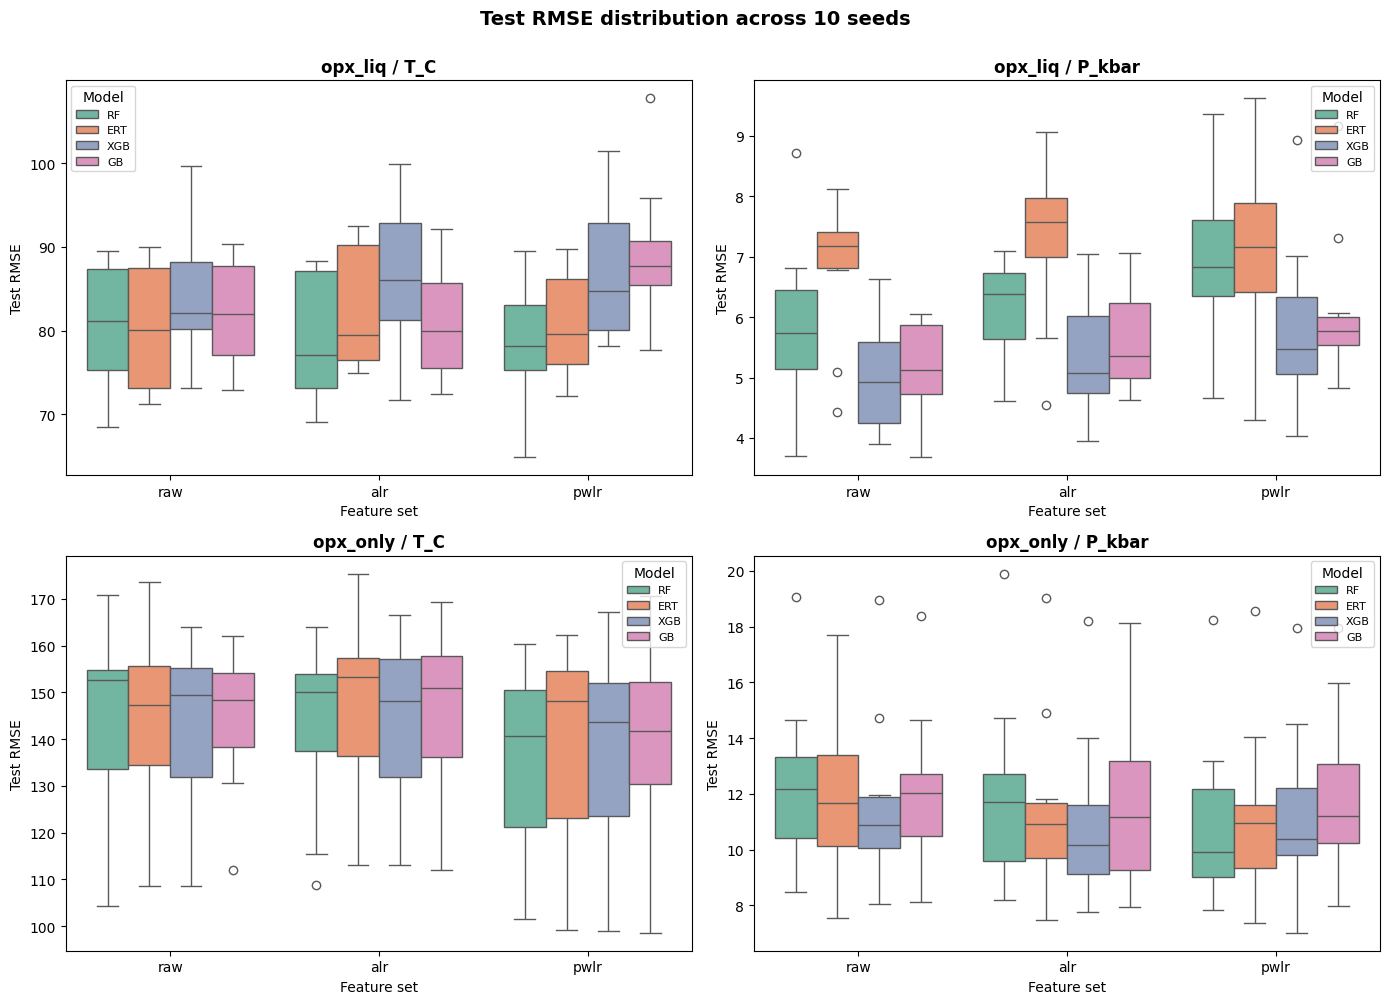

In [11]:
# ===== Boxplot: distribution of test RMSE across 10 seeds =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (track, target) in zip(axes.flat, panels):
    sub = multi_seed_df[(multi_seed_df['track'] == track) &
                        (multi_seed_df['target'] == target)].copy()
    sub['feature_set'] = pd.Categorical(sub['feature_set'],
                                         categories=feat_order, ordered=True)
    sub['model_name'] = pd.Categorical(sub['model_name'],
                                        categories=model_order, ordered=True)
    sns.boxplot(data=sub, x='feature_set', y='rmse_test', hue='model_name',
                ax=ax, palette='Set2')
    ax.set_title(f'{track} / {target}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature set')
    ax.set_ylabel('Test RMSE')
    ax.legend(title='Model', fontsize=8, loc='best')

fig.suptitle('Test RMSE distribution across 10 seeds',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(FIGS / 'fig_nb03c_multiseed_boxplot.png', dpi=300,
            bbox_inches='tight')
plt.show()

In [12]:
# ===== Pairwise feature-set comparison: Wilcoxon signed-rank =====
# Tests whether log-ratio features (alr, pwlr) significantly differ from raw
# baseline within each (track, target, model) combo.
print('=' * 70)
print('FEATURE SET COMPARISON: Wilcoxon signed-rank vs raw baseline')
print('=' * 70)
for (track, target), grp in multi_seed_df.groupby(['track', 'target']):
    print(f'\n--- {track} / {target} ---')
    for mn in model_order:
        raw_arr = (grp[(grp['feature_set'] == 'raw') &
                       (grp['model_name'] == mn)]
                   .sort_values('split_seed')['rmse_test'].values)
        for alt in ['alr', 'pwlr']:
            alt_arr = (grp[(grp['feature_set'] == alt) &
                           (grp['model_name'] == mn)]
                       .sort_values('split_seed')['rmse_test'].values)
            if len(raw_arr) == len(alt_arr) and len(raw_arr) > 0:
                delta = raw_arr - alt_arr  # positive = alt is better
                try:
                    stat, p = stats.wilcoxon(delta, alternative='two-sided')
                except ValueError:
                    p = np.nan
                direction = 'BETTER' if delta.mean() > 0 else 'WORSE'
                sig = ('***' if p < 0.001 else '**' if p < 0.01
                       else '*' if p < 0.05 else '')
                print(f'  [{mn:4s}] raw vs {alt:5s}: '
                      f'delta={delta.mean():+.3f}  p={p:.4f} {sig:3s} '
                      f'{alt} is {direction}')

print('\n* = p<0.05, ** = p<0.01, *** = p<0.001')
logger.info('Diagnostic plots and statistical analysis complete.')

03:24:40 | Diagnostic plots and statistical analysis complete.


FEATURE SET COMPARISON: Wilcoxon signed-rank vs raw baseline

--- opx_liq / P_kbar ---
  [RF  ] raw vs alr  : delta=-0.342  p=0.1309     alr is WORSE
  [RF  ] raw vs pwlr : delta=-1.136  p=0.0371 *   pwlr is WORSE
  [ERT ] raw vs alr  : delta=-0.462  p=0.0137 *   alr is WORSE
  [ERT ] raw vs pwlr : delta=-0.267  p=0.5566     pwlr is WORSE
  [XGB ] raw vs alr  : delta=-0.305  p=0.0059 **  alr is WORSE
  [XGB ] raw vs pwlr : delta=-0.870  p=0.0020 **  pwlr is WORSE
  [GB  ] raw vs alr  : delta=-0.480  p=0.0098 **  alr is WORSE
  [GB  ] raw vs pwlr : delta=-1.015  p=0.0039 **  pwlr is WORSE

--- opx_liq / T_C ---
  [RF  ] raw vs alr  : delta=+1.457  p=0.5566     alr is BETTER
  [RF  ] raw vs pwlr : delta=+1.891  p=0.4316     pwlr is BETTER
  [ERT ] raw vs alr  : delta=-2.149  p=0.0195 *   alr is WORSE
  [ERT ] raw vs pwlr : delta=-0.356  p=0.7695     pwlr is WORSE
  [XGB ] raw vs alr  : delta=-2.307  p=0.2754     alr is WORSE
  [XGB ] raw vs pwlr : delta=-2.957  p=0.0645     pwlr is WORSE

## Phase 3R.5: winner selection and canonical model save

In [13]:
# Phase 3R.5: dynamic global winner selection
agg = multi_seed_df.groupby(
    ['track', 'target', 'feature_set', 'model_name']
).agg(
    rmse_test_mean=('rmse_test', 'mean'),
    rmse_test_std=('rmse_test', 'std'),
    r2_test_mean=('r2_test', 'mean'),
    r2_test_std=('r2_test', 'std'),
    overfit_ratio_mean=('overfit_ratio', 'mean'),
).reset_index()
agg.to_csv(RESULTS / 'nb03_multi_seed_summary.csv', index=False)

best_per_combo = agg.loc[
    agg.groupby(['track', 'target', 'feature_set'])['rmse_test_mean'].idxmin()
].copy()

best_per_combo['feat_rank_within_combo'] = best_per_combo.groupby(
    ['track', 'target']
)['rmse_test_mean'].rank(method='min')

win_counts = best_per_combo[
    best_per_combo['feat_rank_within_combo'] == 1
].groupby('feature_set').size().reindex(FEATURE_METHODS, fill_value=0)

mean_ranks = best_per_combo.groupby(
    'feature_set'
)['feat_rank_within_combo'].mean()

ranking_df = pd.DataFrame({
    'feature_set': FEATURE_METHODS,
    'wins': [int(win_counts.get(f, 0)) for f in FEATURE_METHODS],
    'mean_rank': [float(mean_ranks.get(f, 99)) for f in FEATURE_METHODS],
})
ranking_df = ranking_df.sort_values(
    ['wins', 'mean_rank'], ascending=[False, True]
).reset_index(drop=True)
ranking_df.to_csv(RESULTS / 'nb03_feature_set_ranking.csv', index=False)

global_winner_feat = ranking_df.iloc[0]['feature_set']
runner_up_feat = ranking_df.iloc[1]['feature_set'] if len(ranking_df) > 1 else global_winner_feat

final_configs = {
    'global_feature_set': global_winner_feat,
    'runner_up_feature_set': runner_up_feat,
    'feature_set_ranking': ranking_df.to_dict('records'),
    'per_combo_winners': {},
}

canonical_files_written = []

# Save best (model x target x track) for winner and runner-up
for feat_to_save in [global_winner_feat, runner_up_feat]:
    save_subset = best_per_combo[best_per_combo['feature_set'] == feat_to_save]
    for _, row in save_subset.iterrows():
        track = row['track']
        target = row['target']
        best_model_name = row['model_name']
        winning_model = seed42_models.get(
            (track, target, best_model_name, feat_to_save))
        if winning_model is None:
            print(f'WARNING: missing seed42 model for ({track}, {target}, {best_model_name}, {feat_to_save})')
            continue
        file_name = (f'model_{best_model_name}_{target}_{track}_'
                     f'{feat_to_save}.joblib')
        joblib.dump(winning_model, MODELS / file_name)
        canonical_files_written.append(file_name)

        if feat_to_save == global_winner_feat:
            final_configs['per_combo_winners'][f'{track}_{target}'] = {
                'model_name': best_model_name,
                'feature_set': feat_to_save,
                'rmse_mean': float(row['rmse_test_mean']),
                'rmse_std': float(row['rmse_test_std']),
                'r2_mean': float(row['r2_test_mean']),
                'filename': file_name,
            }

# Save ALL (model x target x track) for global winner
for track_name in ['opx_liq', 'opx_only']:
    for target_name in ['T_C', 'P_kbar']:
        for mn in ['RF', 'ERT', 'XGB', 'GB']:
            mdl = seed42_models.get(
                (track_name, target_name, mn, global_winner_feat))
            if mdl is None:
                continue
            file_name = (f'model_{mn}_{target_name}_{track_name}_'
                         f'{global_winner_feat}.joblib')
            if file_name not in canonical_files_written:
                joblib.dump(mdl, MODELS / file_name)
                canonical_files_written.append(file_name)

with open(RESULTS / 'nb03_winning_configurations.json', 'w') as f:
    json.dump(final_configs, f, indent=2)

# Canonical seed-42 train/test splits
gss42_liq = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_pos, te_pos = next(gss42_liq.split(df_liq,
                                       groups=df_liq['Citation'].values))
np.save(DATA_SPLITS / 'train_indices_opx_liq.npy',
        df_liq.index.values[tr_pos])
np.save(DATA_SPLITS / 'test_indices_opx_liq.npy',
        df_liq.index.values[te_pos])

gss42_opx = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_pos2, te_pos2 = next(gss42_opx.split(df_opx,
                                          groups=df_opx['Citation'].values))
np.save(DATA_SPLITS / 'train_indices_opx.npy',
        df_opx.index.values[tr_pos2])
np.save(DATA_SPLITS / 'test_indices_opx.npy',
        df_opx.index.values[te_pos2])

print(f'Global winner: {global_winner_feat}')
print(f'Runner up: {runner_up_feat}')
print(f'Canonical files saved: {len(canonical_files_written)}')
print(f'\nFeature set ranking:')
print(ranking_df.to_string(index=False))

Global winner: pwlr
Runner up: raw
Canonical files saved: 20

Feature set ranking:
feature_set  wins  mean_rank
       pwlr     3       1.50
        raw     1       2.25
        alr     0       2.25


## Phase 3R.6: save canonical test prediction arrays

In [14]:
with open(RESULTS / 'nb03_winning_configurations.json', 'r') as f:
    config = json.load(f)

win_feat = config['global_feature_set']
test_idx_liq = np.load(DATA_SPLITS / 'test_indices_opx_liq.npy')
df_test_canonical = df_liq.loc[test_idx_liq].copy()

X_test_canonical, _ = build_feature_matrix(df_test_canonical, win_feat,
                                               use_liq=True)

test_preds_canonical = pd.DataFrame({
    'idx': df_test_canonical.index,
    'y_T_true': df_test_canonical['T_C'].values,
    'y_P_true': df_test_canonical['P_kbar'].values,
})

for mn in ['RF', 'ERT', 'XGB', 'GB']:
    fpath_T = MODELS / f'model_{mn}_T_C_opx_liq_{win_feat}.joblib'
    fpath_P = MODELS / f'model_{mn}_P_kbar_opx_liq_{win_feat}.joblib'
    if fpath_T.exists():
        m_T = joblib.load(fpath_T)
        test_preds_canonical[f'T_pred_{mn}'] = predict_median(
            m_T, X_test_canonical)
    if fpath_P.exists():
        m_P = joblib.load(fpath_P)
        test_preds_canonical[f'P_pred_{mn}'] = predict_median(
            m_P, X_test_canonical)

test_preds_canonical.to_csv(
    RESULTS / 'nb03_canonical_test_predictions.csv', index=False)
print(f'Saved canonical test predictions: {len(test_preds_canonical)} rows')

Saved canonical test predictions: 174 rows


## Appendix: N_AUG sensitivity

Justifies the decision to set `N_AUG = 1` and drop the `_aug` feature variants.
Tests `n_aug in {1, 3, 5, 10, 15}` across all three representations, both
targets, and both tracks with default RF and XGB hyperparameters, then runs a
Wilcoxon signed-rank test (1 vs N) per representation. Empirically,
augmentation either hurt or failed to significantly help in every cell, so the
3-method design above is what the manuscript reports.

Writes:
- `results/nb03_n_aug_sensitivity.csv`
- `figures/fig_nb03_n_aug_sensitivity.png`
- `figures/fig_nb03_n_aug_overfit.png`


In [15]:
# Phase 3R.3b: N_AUG sensitivity test
import time
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

N_AUG_TEST = [1, 3, 5, 10, 15]
AUG_TEST_MODELS = ['RF', 'XGB']
AUG_TEST_REPRS = ['raw', 'alr', 'pwlr']
AUG_TEST_TARGETS = ['T_C', 'P_kbar']

n_aug_results = []
total_iters = (len(AUG_TEST_MODELS) * len(N_AUG_TEST) * len(AUG_TEST_REPRS)
               * len(SPLIT_SEEDS) * len(AUG_TEST_TARGETS) * 2)
pbar = tqdm(total=total_iters, desc='N_AUG sensitivity')

for track_name, df_track, use_liq in [('opx_liq', df_liq, True),
                                       ('opx_only', df_opx, False)]:
    for seed in SPLIT_SEEDS:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
        tr_pos, te_pos = next(gss.split(df_track, groups=df_track['Citation'].values))
        df_train = df_track.iloc[tr_pos].copy()
        df_test = df_track.iloc[te_pos].copy()

        for repr_name in AUG_TEST_REPRS:
            X_te, _ = build_feature_matrix(df_test, repr_name, use_liq)

            for n_aug in N_AUG_TEST:
                t0 = time.time()
                if n_aug > 1:
                    df_tr_aug = augment_dataframe(df_train, n_aug=n_aug, seed=seed)
                else:
                    df_tr_aug = df_train.copy()

                X_tr, _ = build_feature_matrix(df_tr_aug, repr_name, use_liq)

                for target in AUG_TEST_TARGETS:
                    y_tr = df_tr_aug[target].values
                    y_te = df_test[target].values

                    for model_name in AUG_TEST_MODELS:
                        est = BASE_MODELS[model_name]()
                        est.fit(X_tr, y_tr)
                        pred_te = predict_median(est, X_te)
                        pred_tr = predict_median(est, X_tr)
                        rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
                        rmse_tr = np.sqrt(mean_squared_error(y_tr, pred_tr))

                        n_aug_results.append({
                            'track': track_name,
                            'model': model_name,
                            'repr': repr_name,
                            'target': target,
                            'n_aug': n_aug,
                            'seed': seed,
                            'rmse_test': rmse_te,
                            'rmse_train': rmse_tr,
                            'r2_test': r2_score(y_te, pred_te),
                            'overfit_ratio': rmse_tr / max(rmse_te, 1e-9),
                        })
                        pbar.update(1)
                        pbar.set_postfix(trk=track_name, m=model_name, r=repr_name,
                                         n=n_aug, s=seed, t=target)

pbar.close()
df_naug = pd.DataFrame(n_aug_results)
df_naug.to_csv(RESULTS / 'nb03_n_aug_sensitivity.csv', index=False)

# ----- Summary table -----
print('=' * 70)
print('N_AUG SENSITIVITY RESULTS (mean +/- std test RMSE)')
print('=' * 70)

summary = (df_naug.groupby(['model', 'track', 'repr', 'target', 'n_aug'])
           .agg(rmse_mean=('rmse_test', 'mean'),
                rmse_std=('rmse_test', 'std'),
                overfit_mean=('overfit_ratio', 'mean'))
           .reset_index())

for (model, track, target), grp in summary.groupby(['model', 'track', 'target']):
    print(f'\n--- {model} | {track} / {target} ---')
    pivot = grp.pivot(index='n_aug', columns='repr', values='rmse_mean')
    pivot_std = grp.pivot(index='n_aug', columns='repr', values='rmse_std')
    for col in pivot.columns:
        pivot[col] = [f'{m:.1f} +/- {s:.1f}'
                      for m, s in zip(pivot[col], pivot_std[col])]
    print(pivot.to_string())

# ----- Wilcoxon signed-rank: n_aug=1 vs each n_aug -----
print('\n' + '=' * 70)
print('WILCOXON SIGNED-RANK TESTS (n_aug=1 vs n_aug=N)')
print('=' * 70)

for (model, track, repr_name, target), grp in df_naug.groupby(['model', 'track', 'repr', 'target']):
    baseline = grp[grp['n_aug'] == 1].sort_values('seed')['rmse_test'].values
    best_rmse, best_n = baseline.mean(), 1
    for n in [3, 5, 10, 15]:
        cand = grp[grp['n_aug'] == n].sort_values('seed')['rmse_test'].values
        if len(cand) == len(baseline):
            delta = baseline - cand
            try:
                stat, p = stats.wilcoxon(delta, alternative='two-sided')
            except ValueError:
                stat, p = np.nan, np.nan
            mean_d = delta.mean()
            direction = 'HELPS' if mean_d > 0 else 'HURTS'
            sig = '*' if p < (0.05 / 4) else ''
            print(f'{model:4s} {track:10s} {repr_name:5s} {target:7s} '
                  f'1 vs {n:2d}: delta={mean_d:+.2f}  p={p:.4f} {sig} {direction}')
            if cand.mean() < best_rmse:
                best_rmse, best_n = cand.mean(), n
    print(f'  -> Best n_aug for {model}/{repr_name}/{target}: {best_n}')

N_AUG sensitivity:   0%|          | 0/1200 [00:00<?, ?it/s]

N_AUG SENSITIVITY RESULTS (mean +/- std test RMSE)

--- RF | opx_liq / P_kbar ---
repr           alr         pwlr          raw
n_aug                                       
1      6.1 +/- 0.8  6.5 +/- 1.2  5.7 +/- 1.3
3      6.6 +/- 1.0  6.6 +/- 1.3  6.0 +/- 0.9
5      6.9 +/- 1.3  6.8 +/- 1.3  5.9 +/- 1.0
10     7.3 +/- 1.1  7.1 +/- 1.3  6.6 +/- 1.6
15     7.4 +/- 1.1  7.2 +/- 1.3  6.7 +/- 1.5

--- RF | opx_liq / T_C ---
repr             alr          pwlr           raw
n_aug                                           
1       80.4 +/- 6.9  80.7 +/- 7.7  80.4 +/- 8.5
3      83.3 +/- 11.8  88.1 +/- 9.4  85.9 +/- 8.0
5      86.1 +/- 12.1  88.7 +/- 8.3  90.5 +/- 8.6
10     90.8 +/- 12.6  88.5 +/- 8.3  92.9 +/- 9.6
15     93.1 +/- 13.4  89.2 +/- 9.8  95.2 +/- 9.8

--- RF | opx_only / P_kbar ---
repr            alr          pwlr           raw
n_aug                                          
1      11.9 +/- 3.4  11.5 +/- 3.1  12.7 +/- 2.8
3      13.5 +/- 2.8  11.9 +/- 3.1  13.6 +/- 2.5
5      1

XGB  opx_only   raw   T_C     1 vs 10: delta=-7.55  p=0.0645  HURTS
XGB  opx_only   raw   T_C     1 vs 15: delta=-8.33  p=0.0371  HURTS
  -> Best n_aug for XGB/raw/T_C: 1


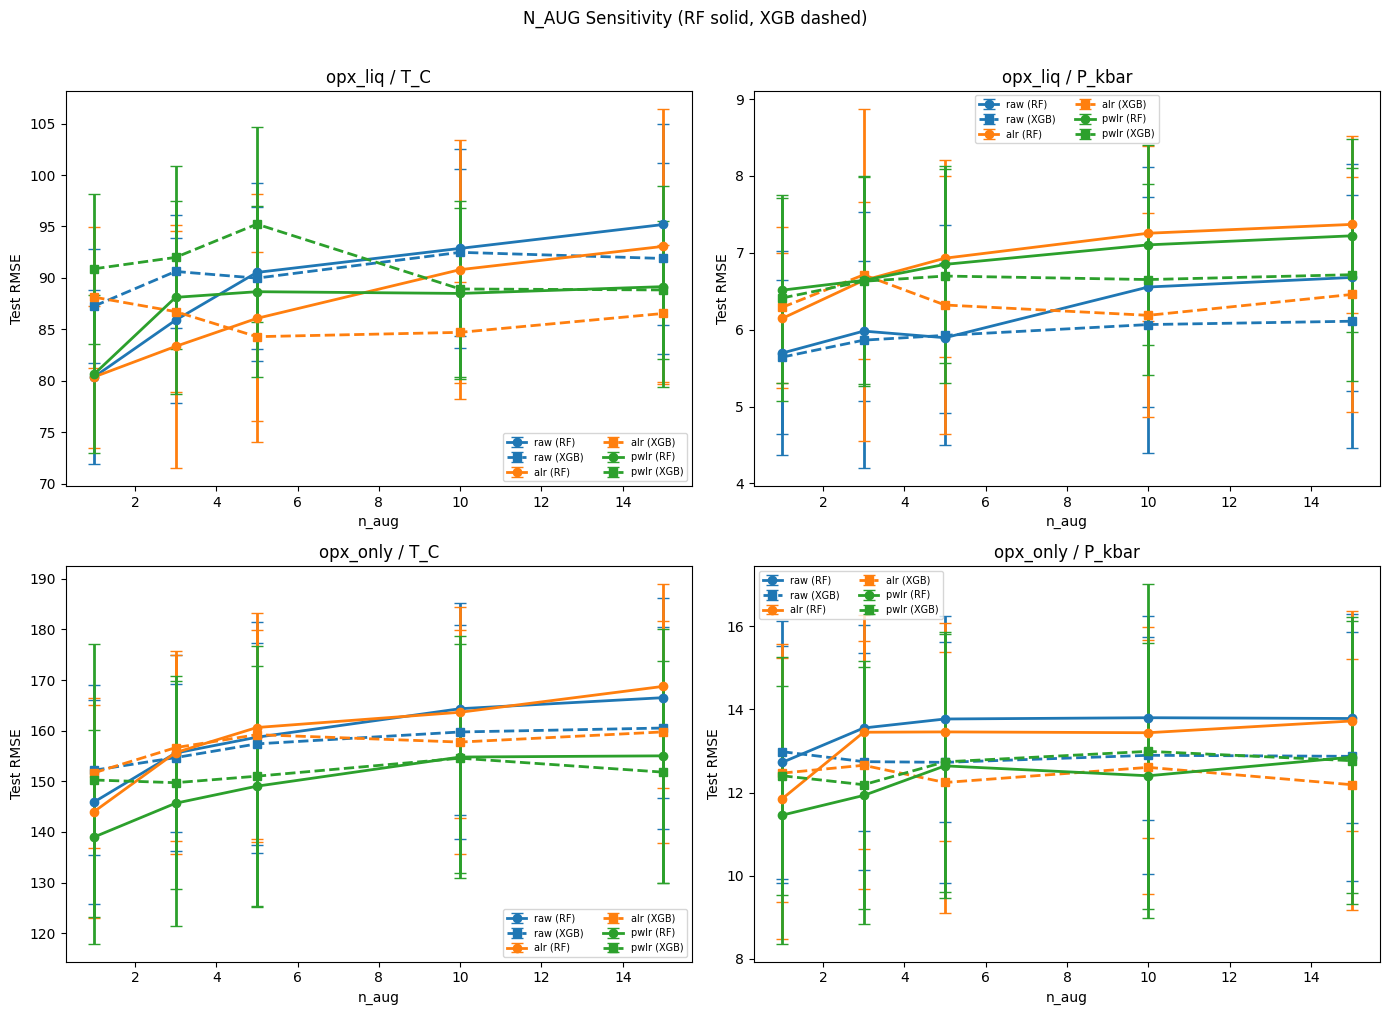

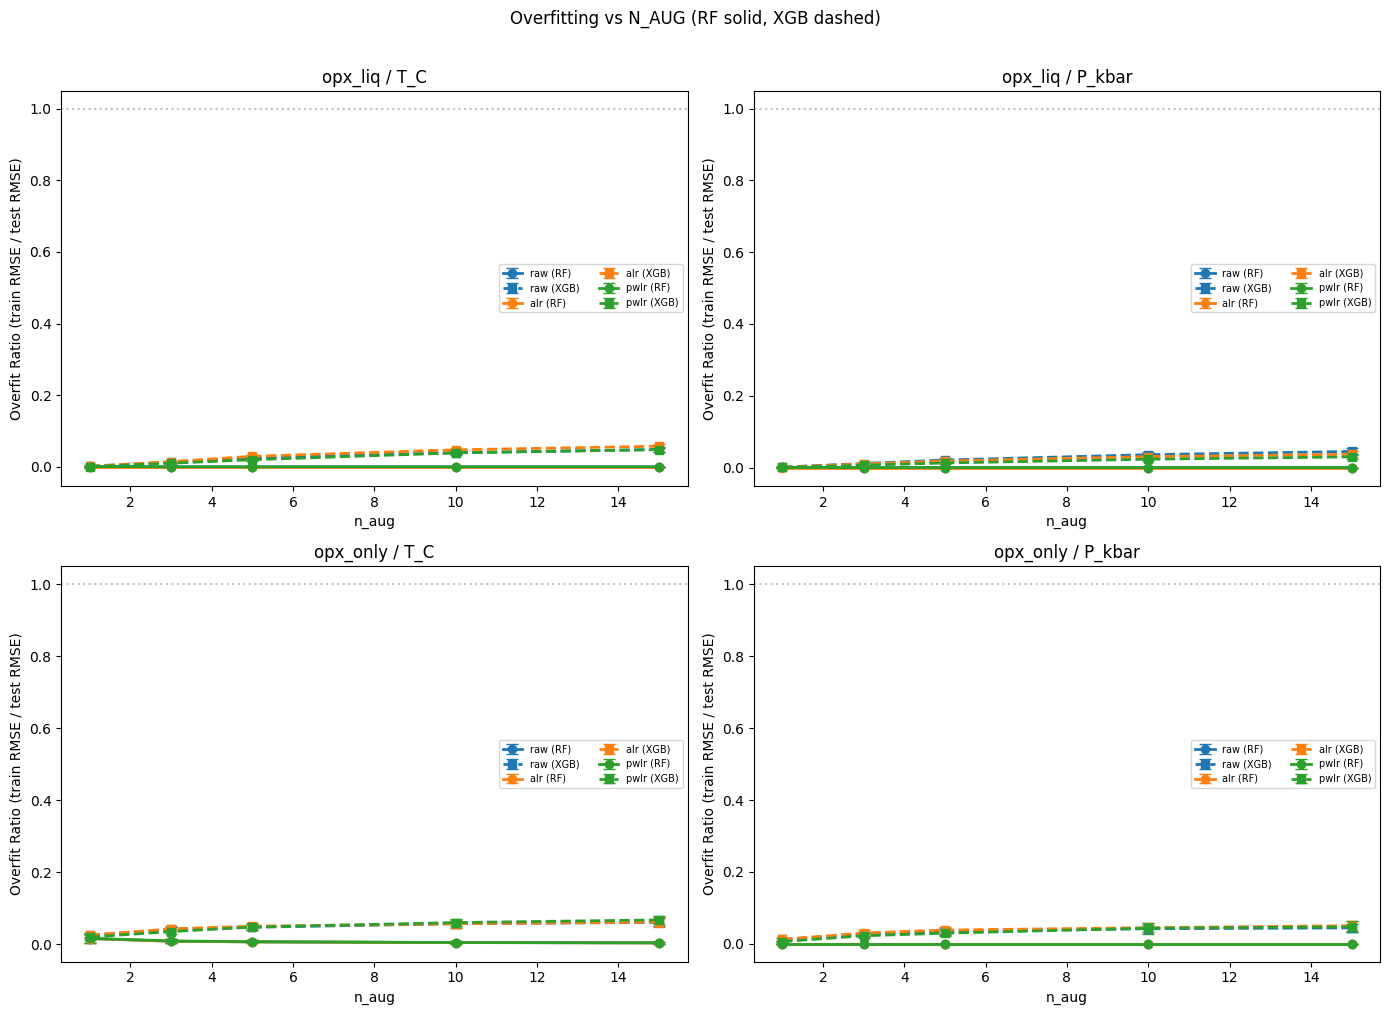


>>> SET N_AUG in the next cell based on these results <<<


In [16]:
# ----- Error bar plot: RMSE vs n_aug -----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
panels = [('opx_liq', 'T_C'), ('opx_liq', 'P_kbar'),
          ('opx_only', 'T_C'), ('opx_only', 'P_kbar')]
colors = {'raw': '#1f77b4', 'alr': '#ff7f0e', 'pwlr': '#2ca02c'}
markers = {'RF': 'o', 'XGB': 's'}

for ax, (track, target) in zip(axes.flat, panels):
    for repr_name, color in colors.items():
        for model_name, marker in markers.items():
            sub = df_naug[(df_naug['track'] == track) &
                          (df_naug['target'] == target) &
                          (df_naug['repr'] == repr_name) &
                          (df_naug['model'] == model_name)]
            m = sub.groupby('n_aug')['rmse_test'].mean()
            s = sub.groupby('n_aug')['rmse_test'].std()
            ax.errorbar(m.index, m.values, yerr=s.values, marker=marker,
                        label=f'{repr_name} ({model_name})', color=color,
                        capsize=4, linewidth=2,
                        linestyle='-' if model_name == 'RF' else '--')
    ax.set_xlabel('n_aug')
    ax.set_ylabel('Test RMSE')
    ax.set_title(f'{track} / {target}')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('N_AUG Sensitivity (RF solid, XGB dashed)', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'fig_nb03_n_aug_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

# ----- Overfit ratio plot -----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (track, target) in zip(axes.flat, panels):
    for repr_name, color in colors.items():
        for model_name, marker in markers.items():
            sub = df_naug[(df_naug['track'] == track) &
                          (df_naug['target'] == target) &
                          (df_naug['repr'] == repr_name) &
                          (df_naug['model'] == model_name)]
            m = sub.groupby('n_aug')['overfit_ratio'].mean()
            s = sub.groupby('n_aug')['overfit_ratio'].std()
            ax.errorbar(m.index, m.values, yerr=s.values, marker=marker,
                        label=f'{repr_name} ({model_name})', color=color,
                        capsize=4, linewidth=2,
                        linestyle='-' if model_name == 'RF' else '--')
    ax.axhline(y=1.0, color='gray', alpha=0.5, linestyle=':')
    ax.set_xlabel('n_aug')
    ax.set_ylabel('Overfit Ratio (train RMSE / test RMSE)')
    ax.set_title(f'{track} / {target}')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('Overfitting vs N_AUG (RF solid, XGB dashed)', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'fig_nb03_n_aug_overfit.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n>>> SET N_AUG in the next cell based on these results <<<')

## Phase 3R.7: verification

Hardened against partial / failed runs.

In [17]:
# Phase 3R.7: verification with informative failures
errors = []

for path in [
    RESULTS / 'nb03_winning_configurations.json',
    RESULTS / 'nb03_multi_seed_results.csv',
    RESULTS / 'nb03_multi_seed_summary.csv',
    RESULTS / 'nb03_feature_set_ranking.csv',
    RESULTS / 'nb03_canonical_test_predictions.csv',
]:
    if not path.exists():
        errors.append(f'MISSING: {path}')

# Row count check
expected_rows = N_SPLIT_REPS * 2 * len(FEATURE_METHODS) * 4 * 2
actual_rows = len(multi_seed_df)
if actual_rows < expected_rows * 0.95:
    errors.append(
        f'multi_seed_df too sparse: got {actual_rows}, expected {expected_rows}')

# NaN check
n_nan = multi_seed_df['rmse_test'].isna().sum()
if n_nan > 0:
    errors.append(f'multi_seed_df has {n_nan} NaN rmse_test rows')

# Config consistency
with open(RESULTS / 'nb03_winning_configurations.json') as f:
    cfg = json.load(f)

if 'global_feature_set' not in cfg:
    errors.append('config missing global_feature_set key')
elif cfg['global_feature_set'] not in FEATURE_METHODS:
    errors.append(f'global_feature_set "{cfg["global_feature_set"]}" not in FEATURE_METHODS')

# Per-combo winners present?
missing_combos = []
for track in ['opx_liq', 'opx_only']:
    for target in ['T_C', 'P_kbar']:
        if f'{track}_{target}' not in cfg.get('per_combo_winners', {}):
            missing_combos.append(f'{track}_{target}')
if missing_combos:
    errors.append(f'config missing per_combo_winners for: {missing_combos}')

if errors:
    print('=== VERIFICATION FAILED ===')
    for e in errors:
        print(f'  - {e}')
    raise AssertionError(f'{len(errors)} verification errors')

print('=== PHASE 3R COMPLETE (NB03c) ===')
print(f'  {len(multi_seed_df)} multi-seed rows (expected {expected_rows})')
print(f'  global feature winner: {cfg["global_feature_set"]}')
print(f'  per_combo_winners: {len(cfg["per_combo_winners"])} entries')
print(f'  canonical files written: {len(canonical_files_written)}')

=== PHASE 3R COMPLETE (NB03c) ===
  480 multi-seed rows (expected 480)
  global feature winner: pwlr
  per_combo_winners: 4 entries
  canonical files written: 20
